## Author: Gracie Grimsrud
## Date: 09/23/2026

Split-half reliability version of `temp_match_overlap_allsubs.ipynb`.
For each subject and each condition (rest, task, task_resid_raw): half 1 vs half 2
consensus + per-half disagreement maps (dscalar), summary CSVs, and a surface PNG.
Then: group summary CSVs and a consensus % bar plot.

Functions live in `pfm_overlap.py` (same folder).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nilearn
import numpy as np
import pandas as pd
from IPython.display import display

code_directory = Path(
    "/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/code/plot_pfm_overlap"
)

if str(code_directory) not in sys.path:
    sys.path.insert(0, str(code_directory))

import pfm_overlap as pfm

print("Python:", sys.executable)
print("nilearn:", nilearn.__version__)
print("pfm_overlap:", pfm.__file__)

Python: /oak/stanford/groups/russpold/users/grimsrud/projects/network-fmri-task/network-fmri/.venv/bin/python
nilearn: 0.14.1
pfm_overlap: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/code/plot_pfm_overlap/pfm_overlap.py


In [2]:
# inputs
analysis_directory = Path(
    "/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis"
)

subjects = ["sub-s03", "sub-s10", "sub-s19", "sub-s29", "sub-s43"]

# {half_name: session}; half names become the input names in every comparison
sessions = {
    "half1": "ses-splithalf1",
    "half2": "ses-splithalf2",
}

common_suffix = (
    "ReproTM_template-ABCC2026-a3-9to16_refine-SCAN_minsize-30.dscalar.nii"
)

# one two-way comparison (half1 vs half2) per condition
condition_config = {
    "rest": {
        "base_directory": analysis_directory / "temp_match_results_splithalf",
        "task": "rest",
    },
    "task": {
        "base_directory": analysis_directory / "temp_match_results_splithalf",
        "task": "task",
    },
    "task_resid_raw": {
        "base_directory": analysis_directory / "temp_match_results_splithalf_raw_resid",
        "task": "taskresidRAW",
    },
}

map_index = 0

# outputs
output_root = (
    analysis_directory
    / "temp_match_overlap"
    / "23Sept2026_splithalf"
    / "network_overlap_outputs"
)

group_output_directory = output_root / "group"

overwrite_outputs = True

# surfaces + figure settings
left_surface_path = Path(
    "/oak/stanford/groups/russpold/users/grimsrud/data/fsLR/fs_LR.32k.L.midthickness.surf.gii"
)

right_surface_path = Path(
    "/oak/stanford/groups/russpold/users/grimsrud/data/fsLR/fs_LR.32k.R.midthickness.surf.gii"
)

surface_views = [
    ("left", "lateral", left_surface_path),
    ("left", "medial", left_surface_path),
    ("right", "lateral", right_surface_path),
    ("right", "medial", right_surface_path),
]

panel_zoom = 1.4
legend_fontsize = 13

# e.g. "splithalf-rest"; used in every output filename
comparison_names = {
    condition: f"splithalf-{pfm.safe_filename_component(condition)}"
    for condition in condition_config
}

print("Comparisons:", list(comparison_names.values()))
print("Output root:", output_root)

Comparisons: ['splithalf-rest', 'splithalf-task', 'splithalf-task_resid_raw']
Output root: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs


In [3]:
# check every input (dscalar + dlabel) for every subject, condition, and half
for surface_path in (left_surface_path, right_surface_path):
    if not surface_path.is_file():
        raise FileNotFoundError(f"Missing surface:\n{surface_path}")

# {subject: {condition: {half_name: dscalar_path}}}
input_files_by_subject = {
    subject: {
        condition: pfm.build_splithalf_input_files(
            base_directory=config["base_directory"],
            subject=subject,
            task=config["task"],
            sessions=sessions,
            common_suffix=common_suffix,
        )
        for condition, config in condition_config.items()
    }
    for subject in subjects
}

input_check_rows = []

for subject, files_by_condition in input_files_by_subject.items():
    for condition, input_files in files_by_condition.items():
        for half_name, dscalar_path in input_files.items():
            dlabel_path = pfm.corresponding_dlabel_path(dscalar_path)

            input_check_rows.append({
                "subject": subject,
                "input": f"{condition} {half_name}",
                "dscalar": "FOUND" if dscalar_path.is_file() else "MISSING",
                "dlabel": "FOUND" if dlabel_path.is_file() else "MISSING",
            })

input_check = pd.DataFrame(input_check_rows)

display(
    input_check.pivot(
        index="subject",
        columns="input",
        values=["dscalar", "dlabel"],
    )
)

missing = input_check[
    (input_check["dscalar"] == "MISSING")
    | (input_check["dlabel"] == "MISSING")
]

if not missing.empty:
    raise FileNotFoundError(f"Missing inputs:\n{missing}")

print("All inputs found.")

dscalar                                                        \
input   rest half1 rest half2 task half1 task half2 task_resid_raw half1   
subject                                                                    
sub-s03      FOUND      FOUND      FOUND      FOUND                FOUND   
sub-s10      FOUND      FOUND      FOUND      FOUND                FOUND   
sub-s19      FOUND      FOUND      FOUND      FOUND                FOUND   
sub-s29      FOUND      FOUND      FOUND      FOUND                FOUND   
sub-s43      FOUND      FOUND      FOUND      FOUND                FOUND   

                                 dlabel                                   \
input   task_resid_raw half2 rest half1 rest half2 task half1 task half2   
subject                                                                    
sub-s03                FOUND      FOUND      FOUND      FOUND      FOUND   
sub-s10                FOUND      FOUND      FOUND      FOUND      FOUND   
sub-s19                FOUND      FOUND      FOUND      FOUND      FOUND   
sub-s29                FOUND      FOUND      FOUND      FOUND      FOUND   
sub-s43                FOUND      FOUND      FOUND      FOUND      FOUND   

                                                   
input   task_resid_raw half1 task_resid_raw half2  
subject                                            
sub-s03                FOUND                FOUND  
sub-s10                FOUND                FOUND  
sub-s19                FOUND                FOUND  
sub-s29                FOUND                FOUND  
sub-s43                FOUND                FOUND

All inputs found.


In [4]:
# network names/colors from one dlabel; confirm every dlabel uses the same table
all_dscalar_paths = [
    dscalar_path
    for files_by_condition in input_files_by_subject.values()
    for input_files in files_by_condition.values()
    for dscalar_path in input_files.values()
]

reference_dlabel_path = pfm.corresponding_dlabel_path(all_dscalar_paths[0])

network_labels, network_colors = pfm.load_label_table(
    reference_dlabel_path,
    map_index,
)

for dscalar_path in all_dscalar_paths:
    dlabel_path = pfm.corresponding_dlabel_path(dscalar_path)
    labels, colors = pfm.load_label_table(dlabel_path, map_index)

    if labels != network_labels or colors != network_colors:
        raise ValueError(
            f"Label table in {dlabel_path.name} differs from "
            f"{reference_dlabel_path.name}"
        )

print(f"All {len(all_dscalar_paths)} dlabel tables match.\n")

for network_id in sorted(network_labels):
    print(
        f"{network_id}: "
        f"{network_labels[network_id]!r}, "
        f"RGBA={network_colors[network_id]}"
    )

dlabel_network_cmap, color_min, color_max = pfm.make_network_cmap(
    network_colors,
    pfm.BACKGROUND_VALUES,
)

print("\nBackground values:", sorted(pfm.BACKGROUND_VALUES))
print("Color limits:", color_min, color_max)

All 30 dlabel tables match.

0: '???', RGBA=(1.0, 1.0, 1.0, 0.0)
1: 'Default_Mode_net', RGBA=(1.0, 0.0, 0.0, 1.0)
2: 'Visual_net', RGBA=(0.0, 0.0, 0.54902, 1.0)
3: 'Frontoparietal_net', RGBA=(0.992157, 0.992157, 0.0, 1.0)
4: 'unlabelled4', RGBA=(0.247059, 0.247059, 0.247059, 1.0)
5: 'Dorsal_Attention_net', RGBA=(0.00392157, 0.796078, 0.00392157, 1.0)
6: 'unlabelled6', RGBA=(0.247059, 0.247059, 0.247059, 1.0)
7: 'Ventral_Attention_net', RGBA=(0.0, 0.6, 0.6, 1.0)
8: 'Salience_net', RGBA=(0.0, 0.0, 0.0, 1.0)
9: 'Action-Mode_net', RGBA=(0.294118, 0.0, 0.596078, 1.0)
10: 'Sensorimotor_Dorsal_net', RGBA=(0.203922, 0.996078, 0.992157, 1.0)
11: 'Sensorimotor_Lateral_net', RGBA=(0.996078, 0.494118, 0.00392157, 1.0)
12: 'Auditory_net', RGBA=(0.596078, 0.2, 0.996078, 1.0)
13: 'Temporal_Pole_net', RGBA=(0.0, 0.2, 0.4, 1.0)
14: 'Medial_Temporal_Lobe_net', RGBA=(0.196078, 0.996078, 0.2, 1.0)
15: 'Parietal_Memory_net', RGBA=(0.0, 0.00392157, 0.992157, 1.0)
16: 'Parietal_Occipital_net', RGBA=(0.992157

In [5]:
# overlap: half1 vs half2 for each subject and condition; save dscalars + CSVs
# results[(subject, condition)] = {"input_names", "overlap", "paths"}
results = {}

for subject in subjects:
    for condition, comparison_name in comparison_names.items():
        loaded = pfm.load_assignments(
            input_files_by_subject[subject][condition],
            map_index,
        )

        overlap = pfm.compute_overlap(
            loaded["assignments"],
            loaded["background"],
            loaded["input_names"],
            network_labels,
        )

        output_paths = pfm.save_overlap_outputs(
            overlap,
            loaded,
            subject=subject,
            comparison_name=comparison_name,
            output_directory=output_root / subject,
            overwrite=overwrite_outputs,
        )

        results[(subject, condition)] = {
            "input_names": loaded["input_names"],
            "overlap": overlap,
            "paths": output_paths,
        }

        n_consensus = overlap["consensus_mask"].sum()
        n_all_assigned = overlap["all_assigned"].sum()

        print(
            f"{subject} {condition}: consensus {n_consensus:,} / {n_all_assigned:,} "
            f"assigned-in-both-halves "
            f"({100 * n_consensus / n_all_assigned:.2f}%), "
            f"disagreement {overlap['disagreement_mask'].sum():,}"
        )

    print(f"  saved to {output_root / subject}")

sub-s03 rest: consensus 69,799 / 89,920 assigned-in-both-halves (77.62%), disagreement 20,533
sub-s03 task: consensus 82,279 / 90,375 assigned-in-both-halves (91.04%), disagreement 8,241
sub-s03 task_resid_raw: consensus 80,459 / 90,318 assigned-in-both-halves (89.08%), disagreement 10,027
  saved to /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s03
sub-s10 rest: consensus 72,503 / 90,049 assigned-in-both-halves (80.52%), disagreement 17,828
sub-s10 task: consensus 80,513 / 90,266 assigned-in-both-halves (89.20%), disagreement 9,936
sub-s10 task_resid_raw: consensus 78,833 / 90,138 assigned-in-both-halves (87.46%), disagreement 11,540
  saved to /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s10
sub-s19 rest: consensus 71,176 / 90,385 assigned-in-both-halves (78.75%), disagreement 19,376
sub-s19 

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s03/sub-s03_splithalf-rest_disagreement_consensus_surfaces.png


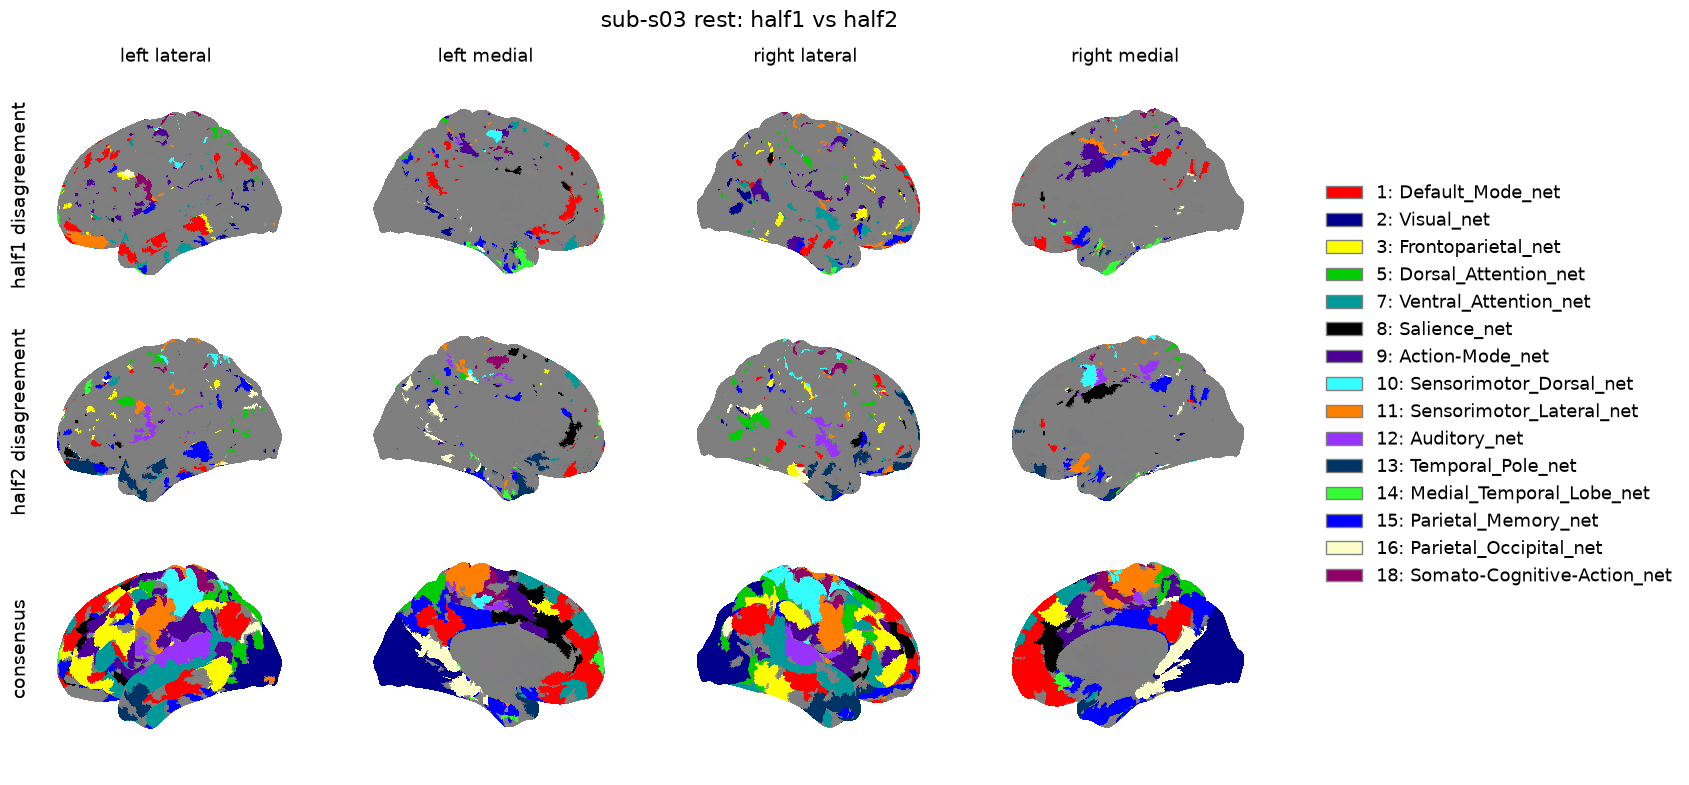

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s03/sub-s03_splithalf-task_disagreement_consensus_surfaces.png


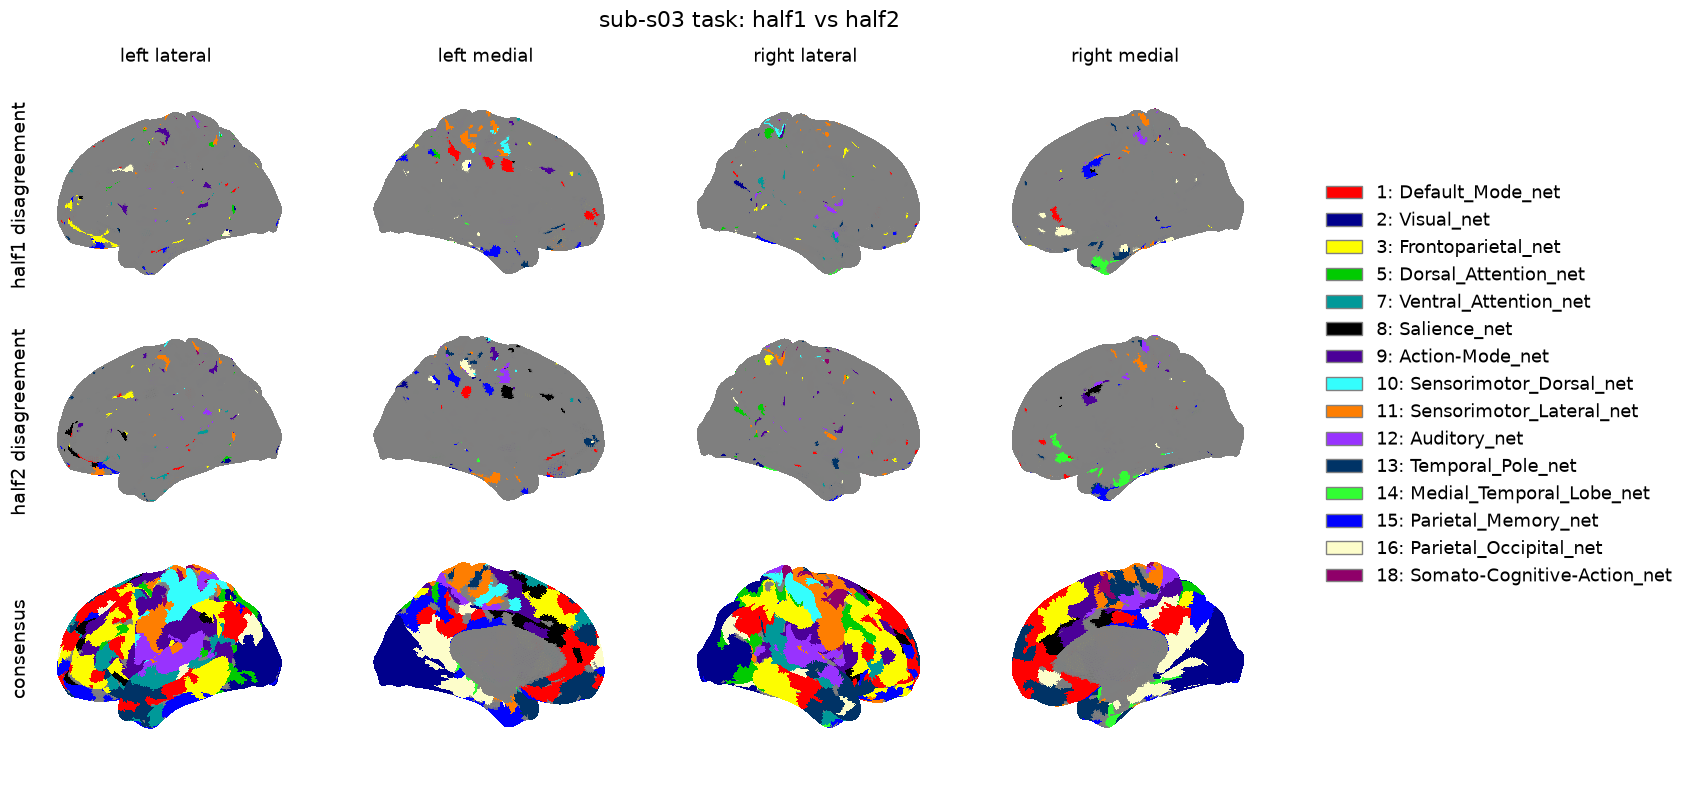

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s03/sub-s03_splithalf-task_resid_raw_disagreement_consensus_surfaces.png


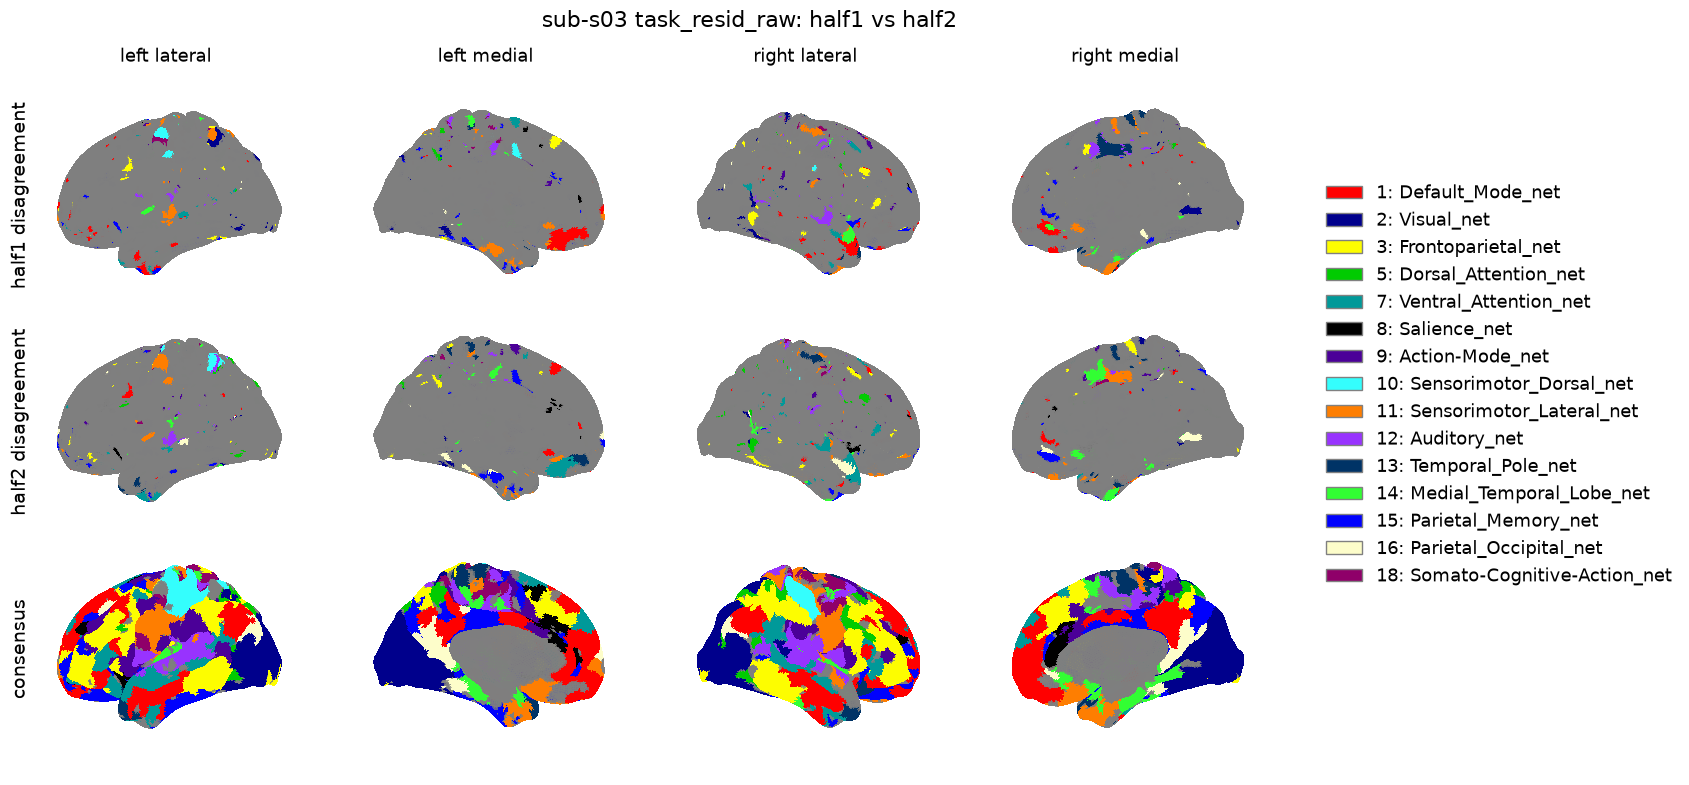

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s10/sub-s10_splithalf-rest_disagreement_consensus_surfaces.png


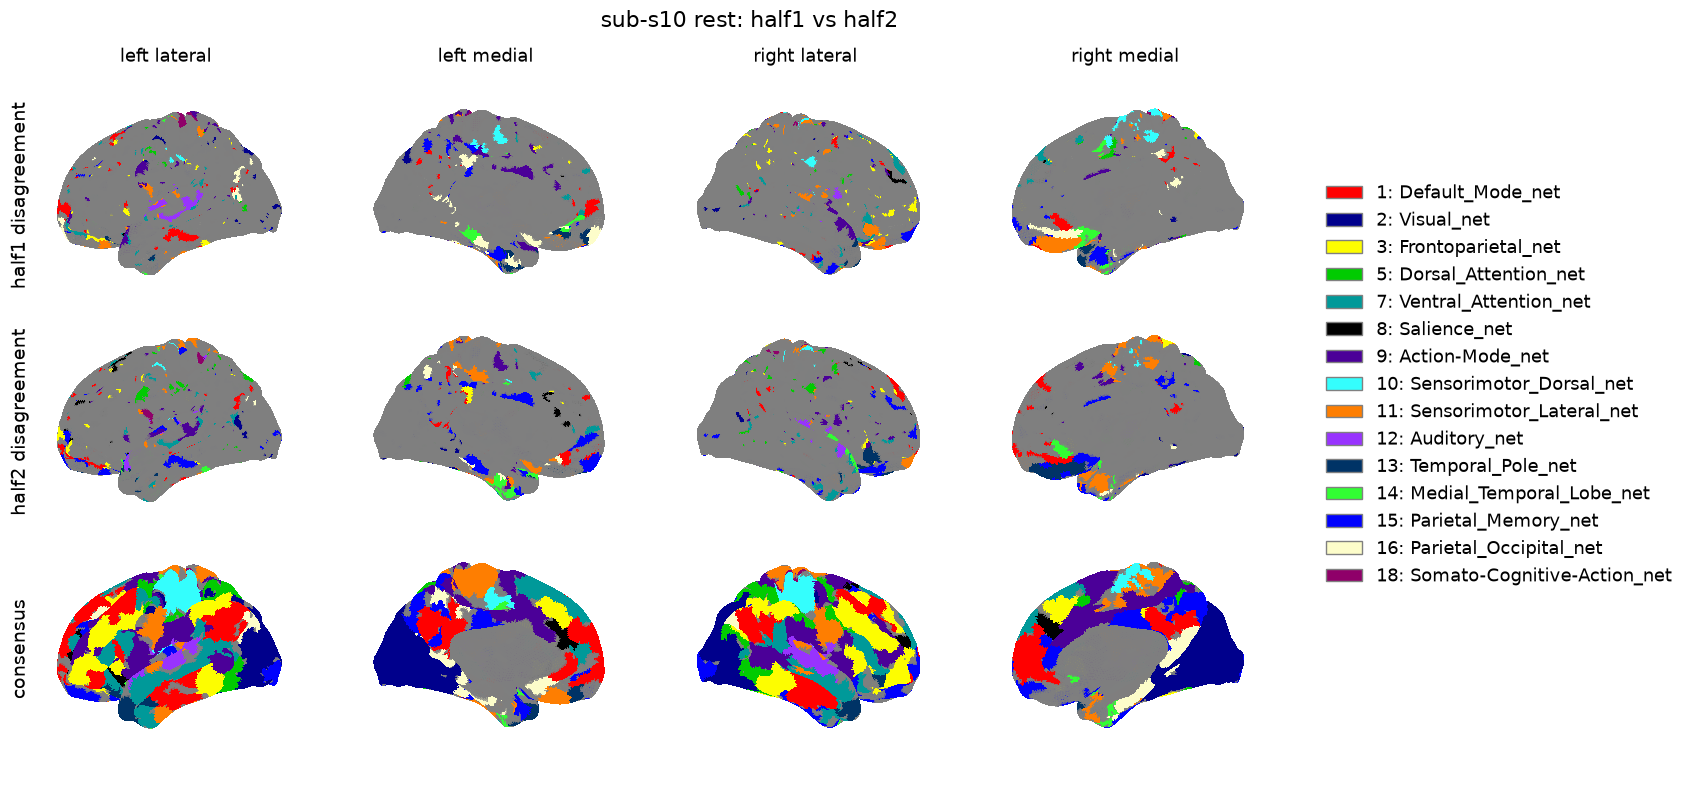

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s10/sub-s10_splithalf-task_disagreement_consensus_surfaces.png


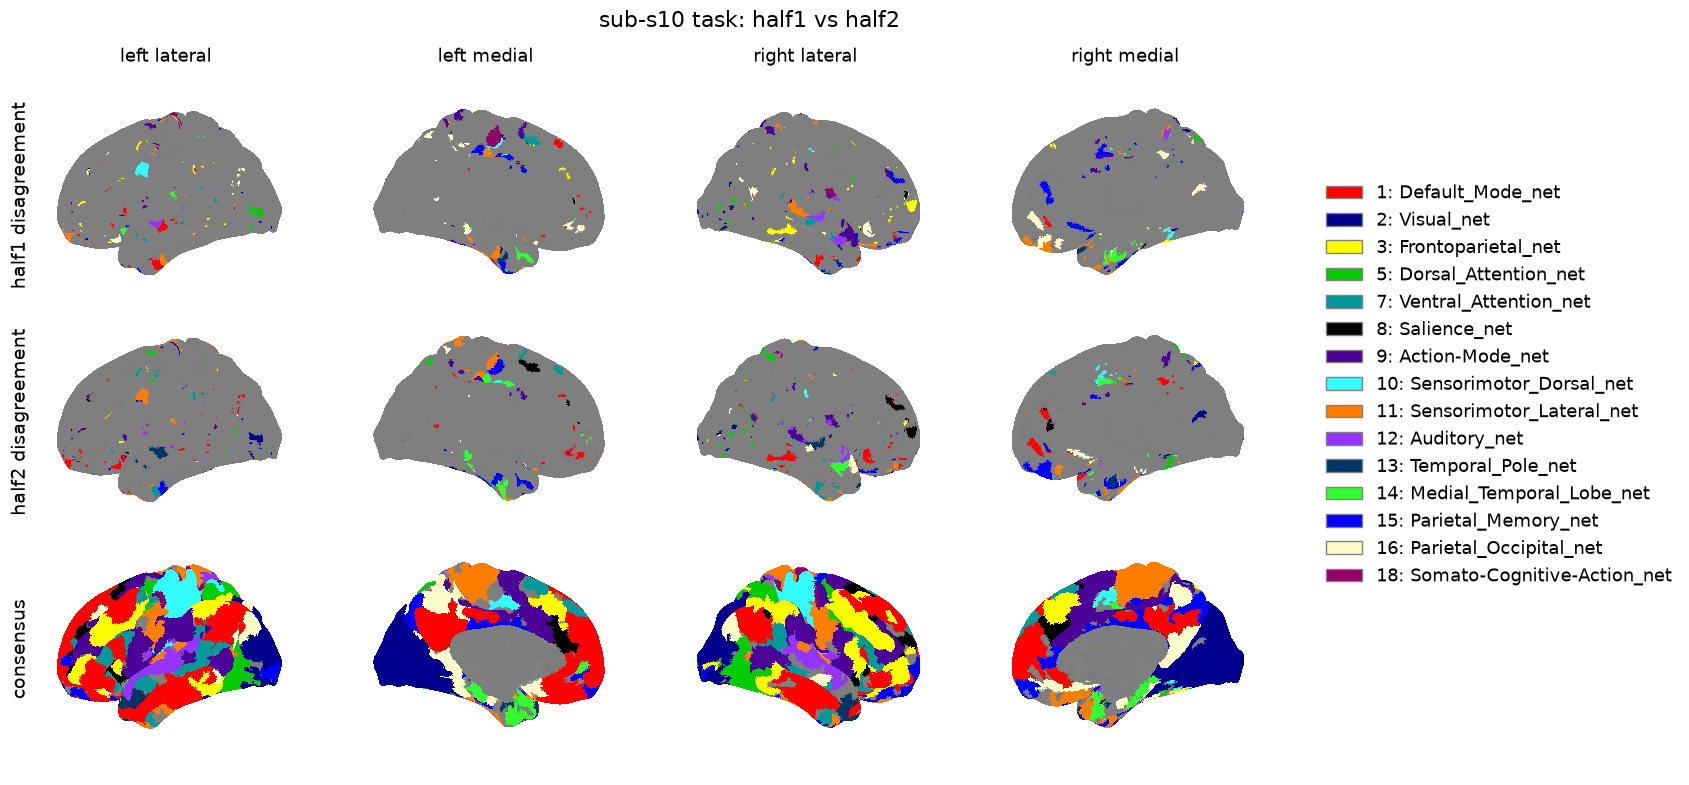

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s10/sub-s10_splithalf-task_resid_raw_disagreement_consensus_surfaces.png


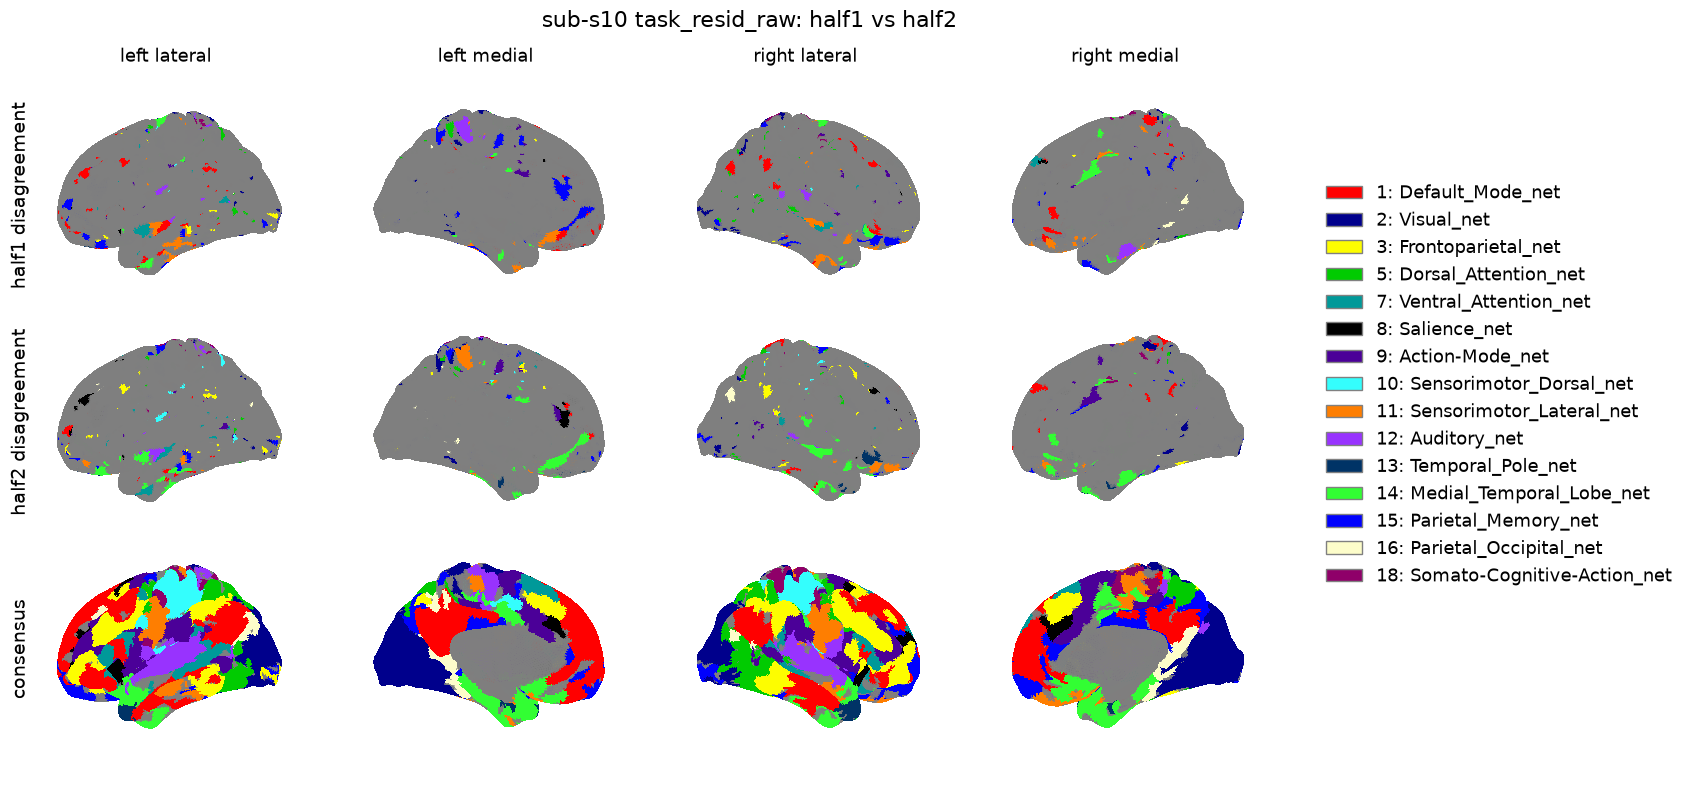

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s19/sub-s19_splithalf-rest_disagreement_consensus_surfaces.png


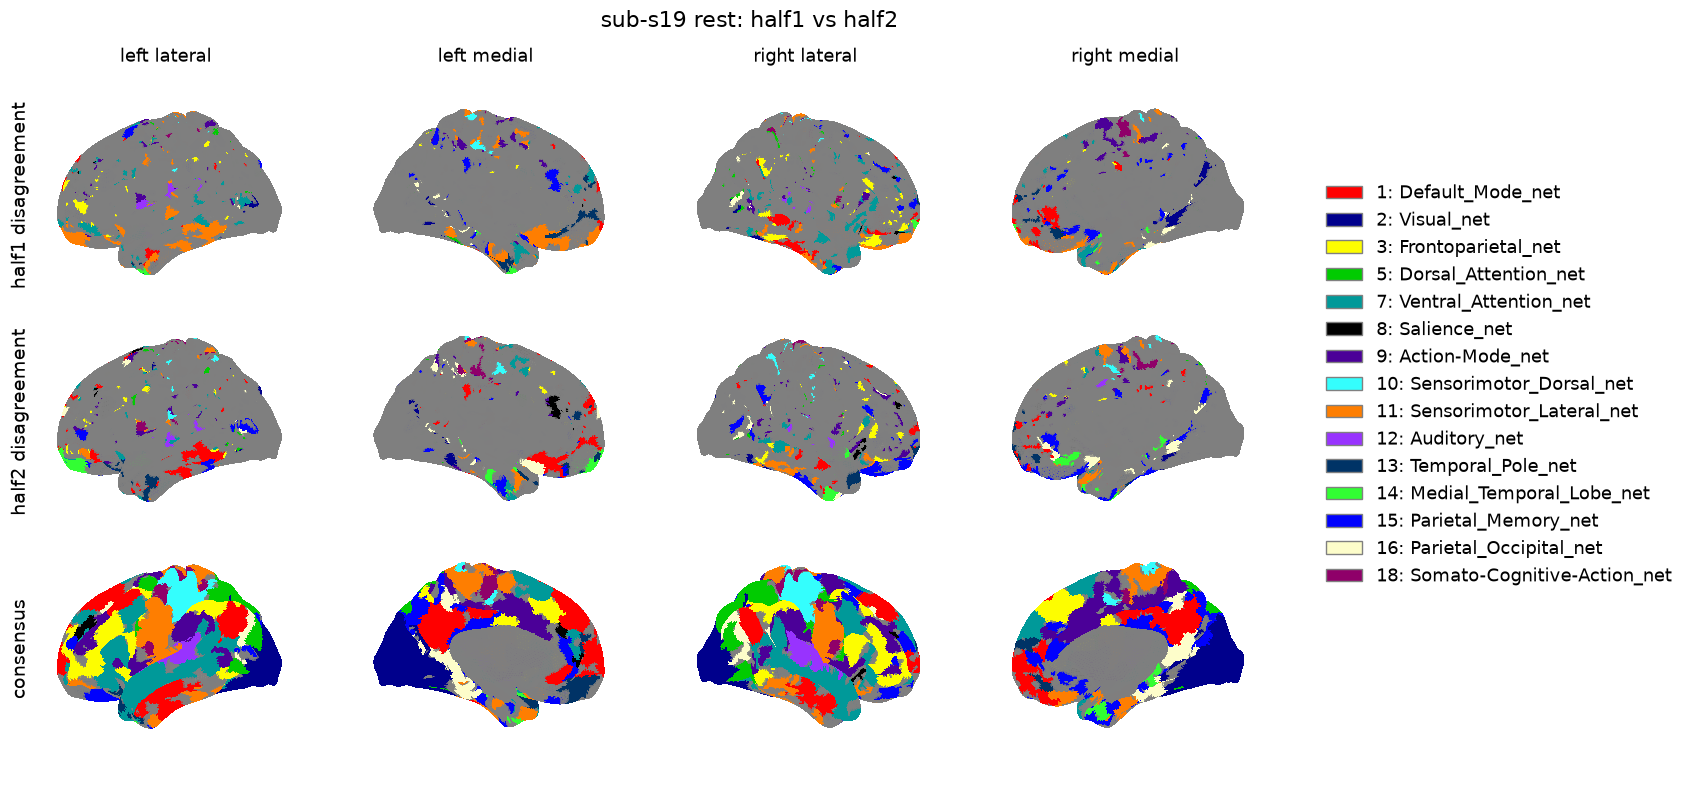

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s19/sub-s19_splithalf-task_disagreement_consensus_surfaces.png


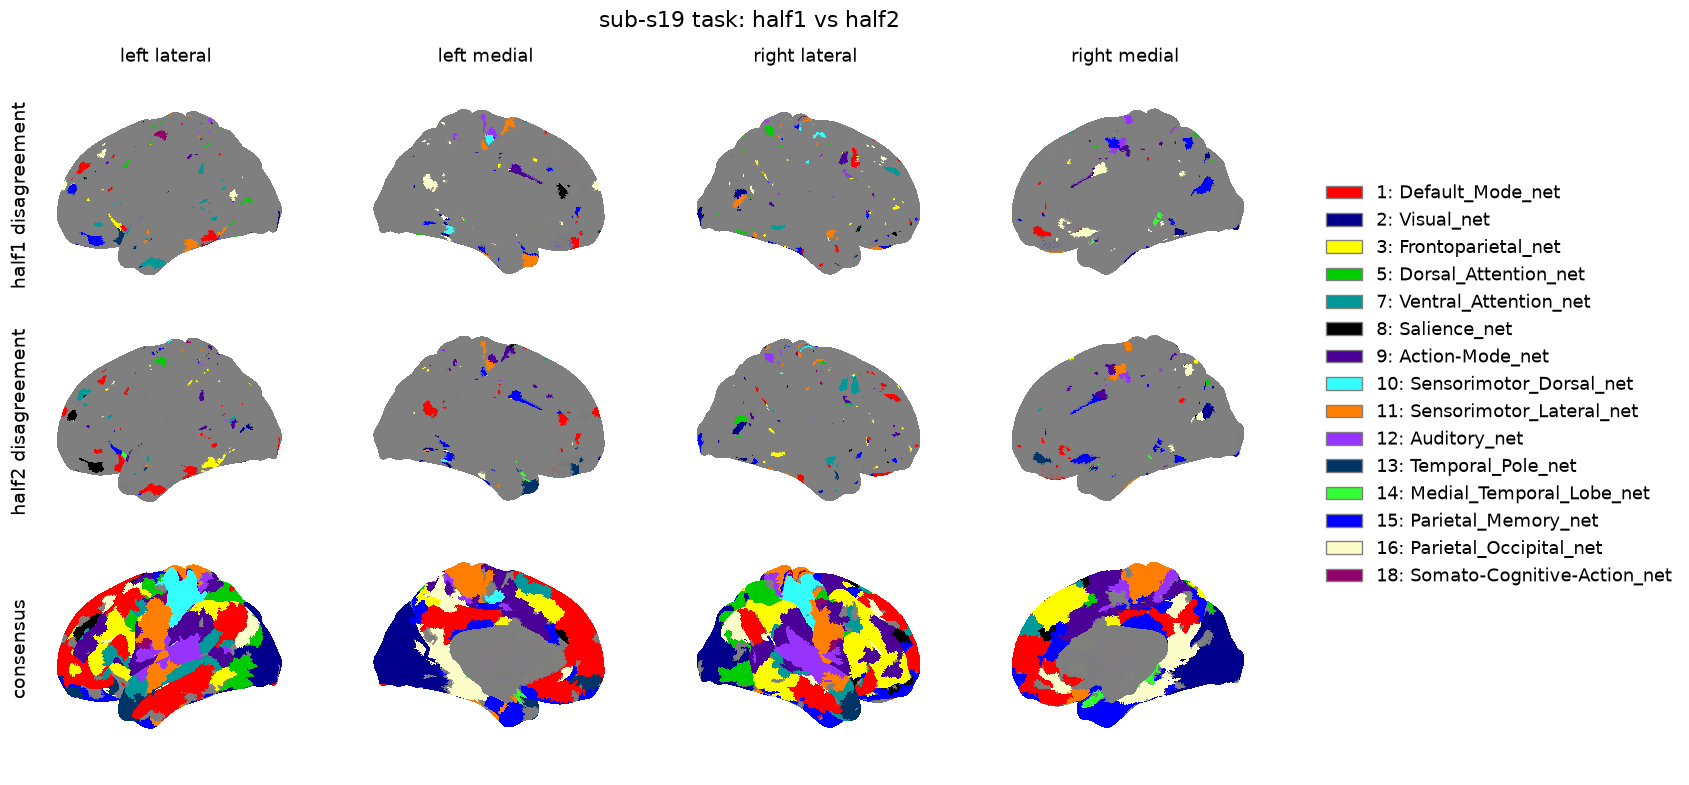

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s19/sub-s19_splithalf-task_resid_raw_disagreement_consensus_surfaces.png


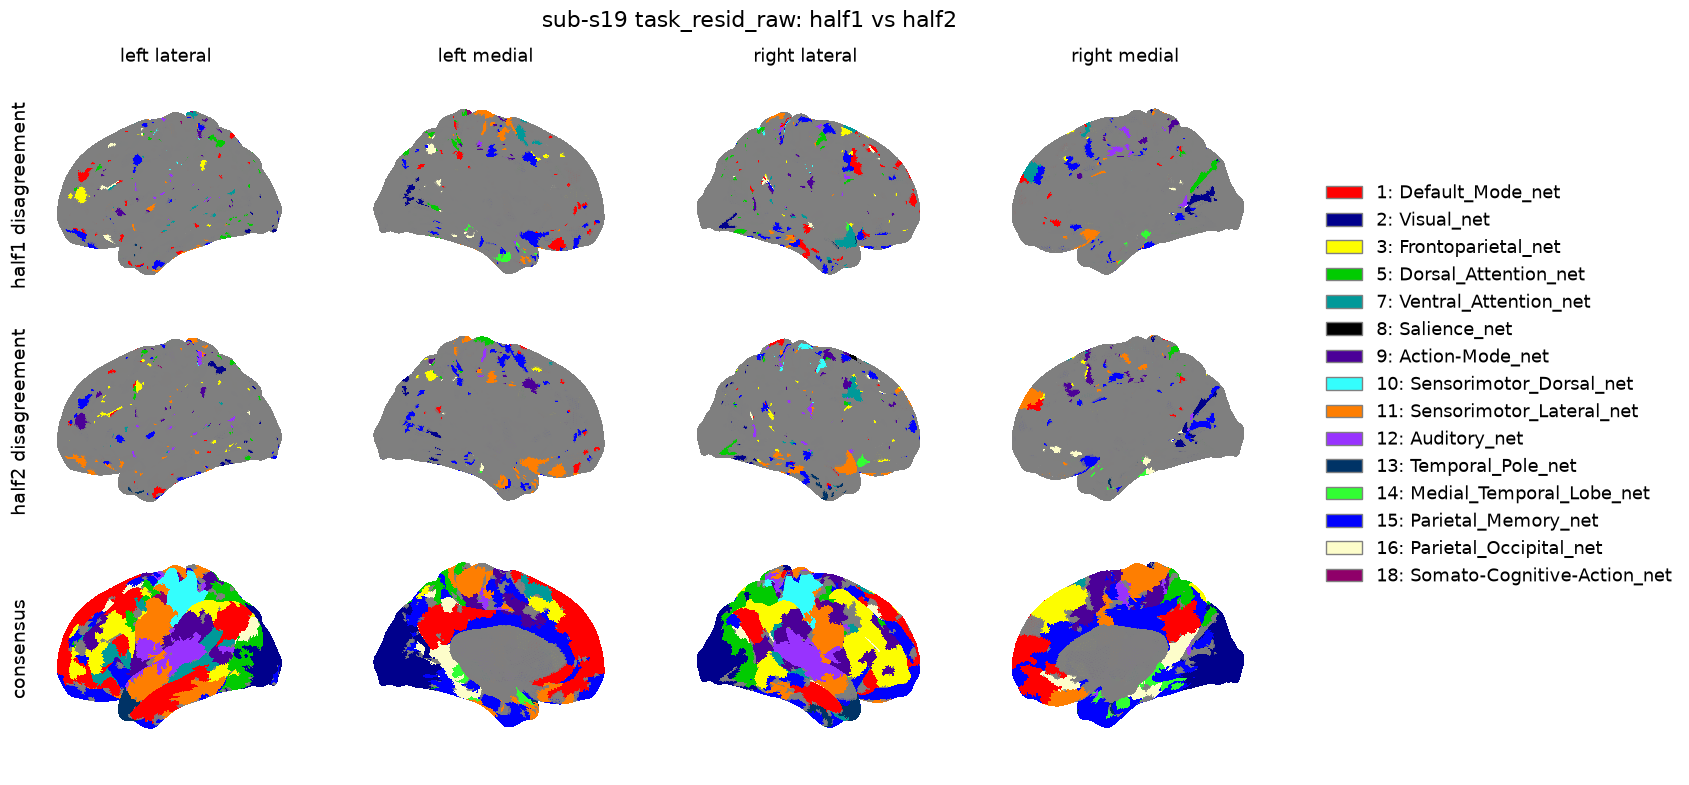

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s29/sub-s29_splithalf-rest_disagreement_consensus_surfaces.png


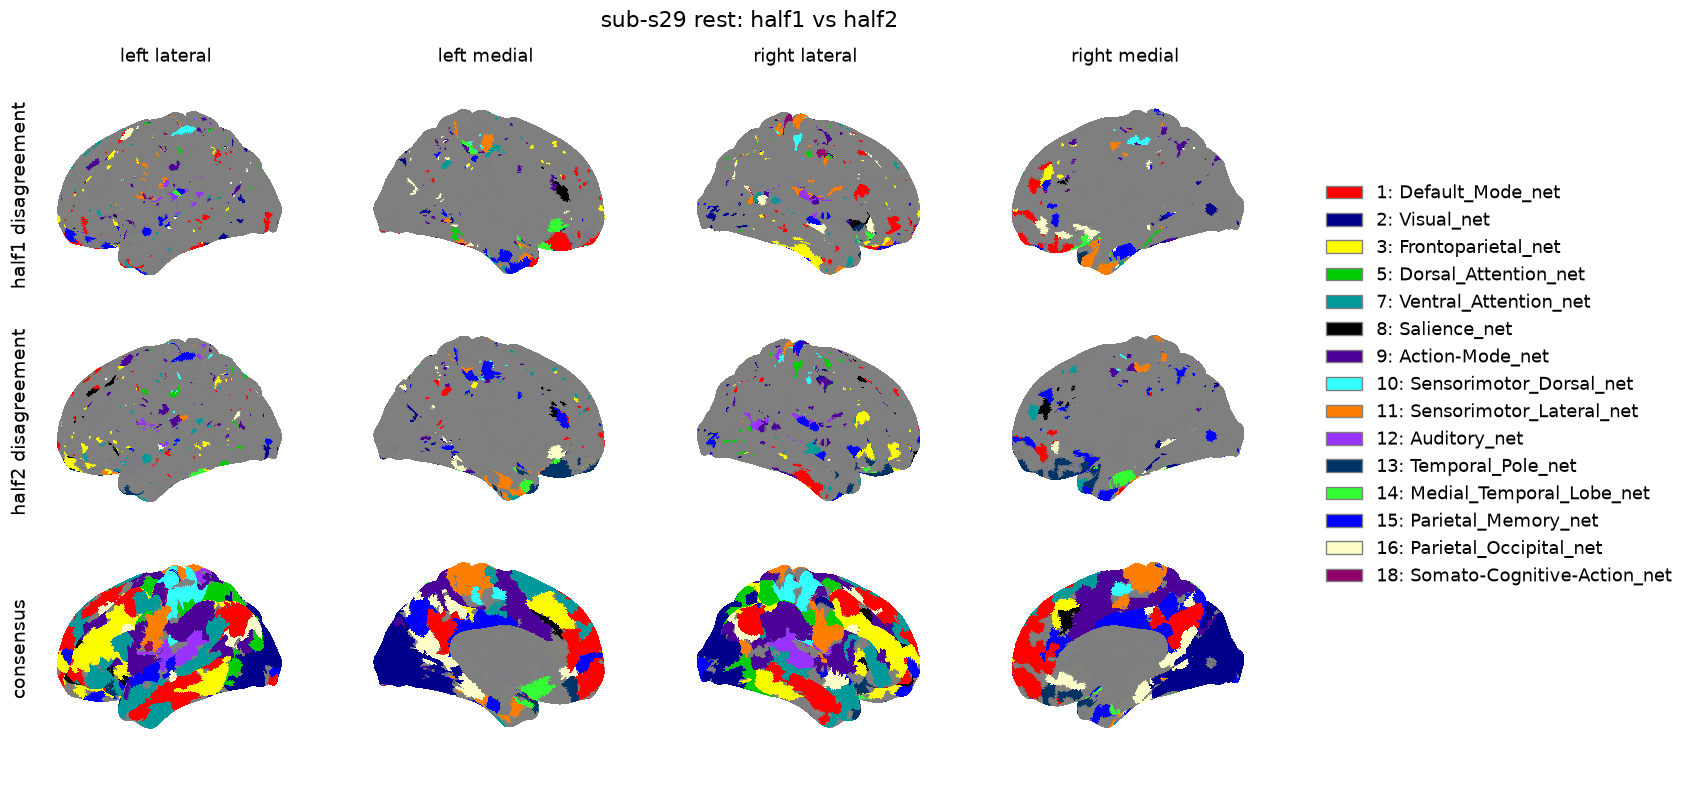

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s29/sub-s29_splithalf-task_disagreement_consensus_surfaces.png


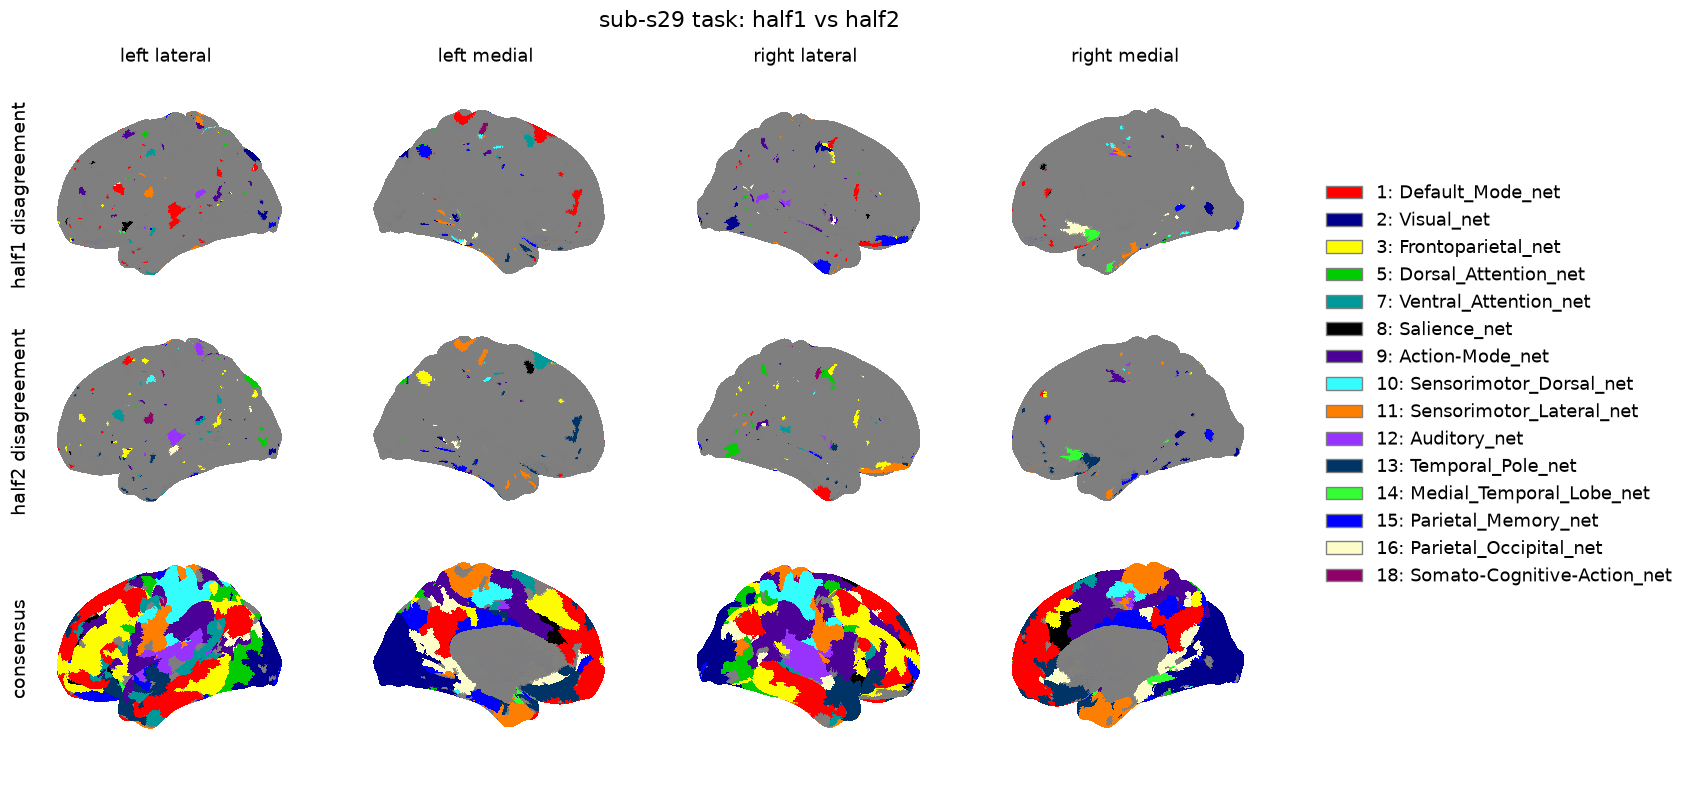

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s29/sub-s29_splithalf-task_resid_raw_disagreement_consensus_surfaces.png


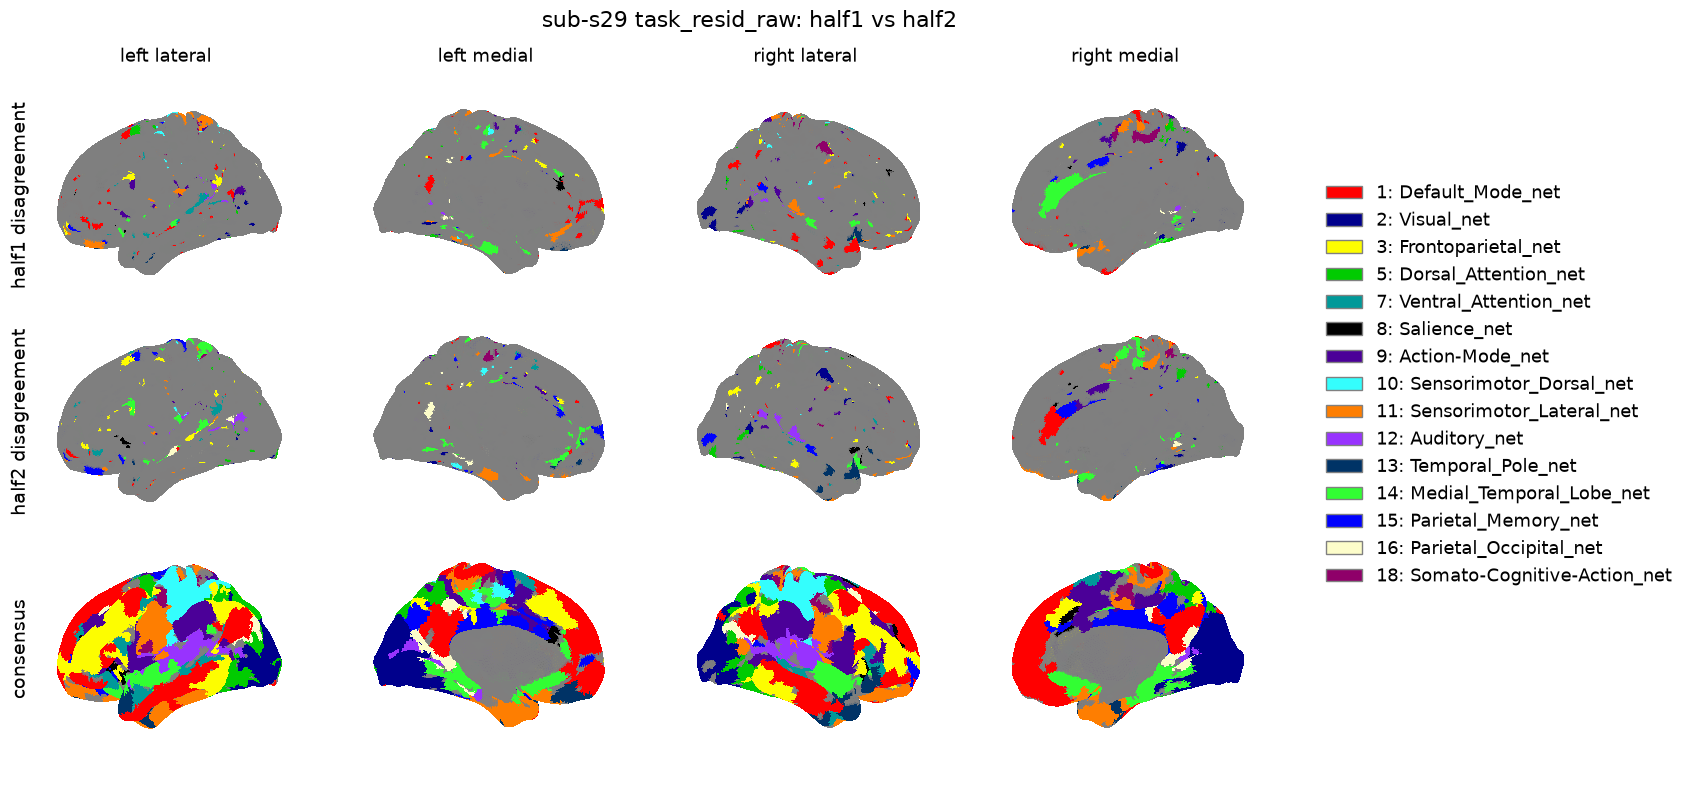

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s43/sub-s43_splithalf-rest_disagreement_consensus_surfaces.png


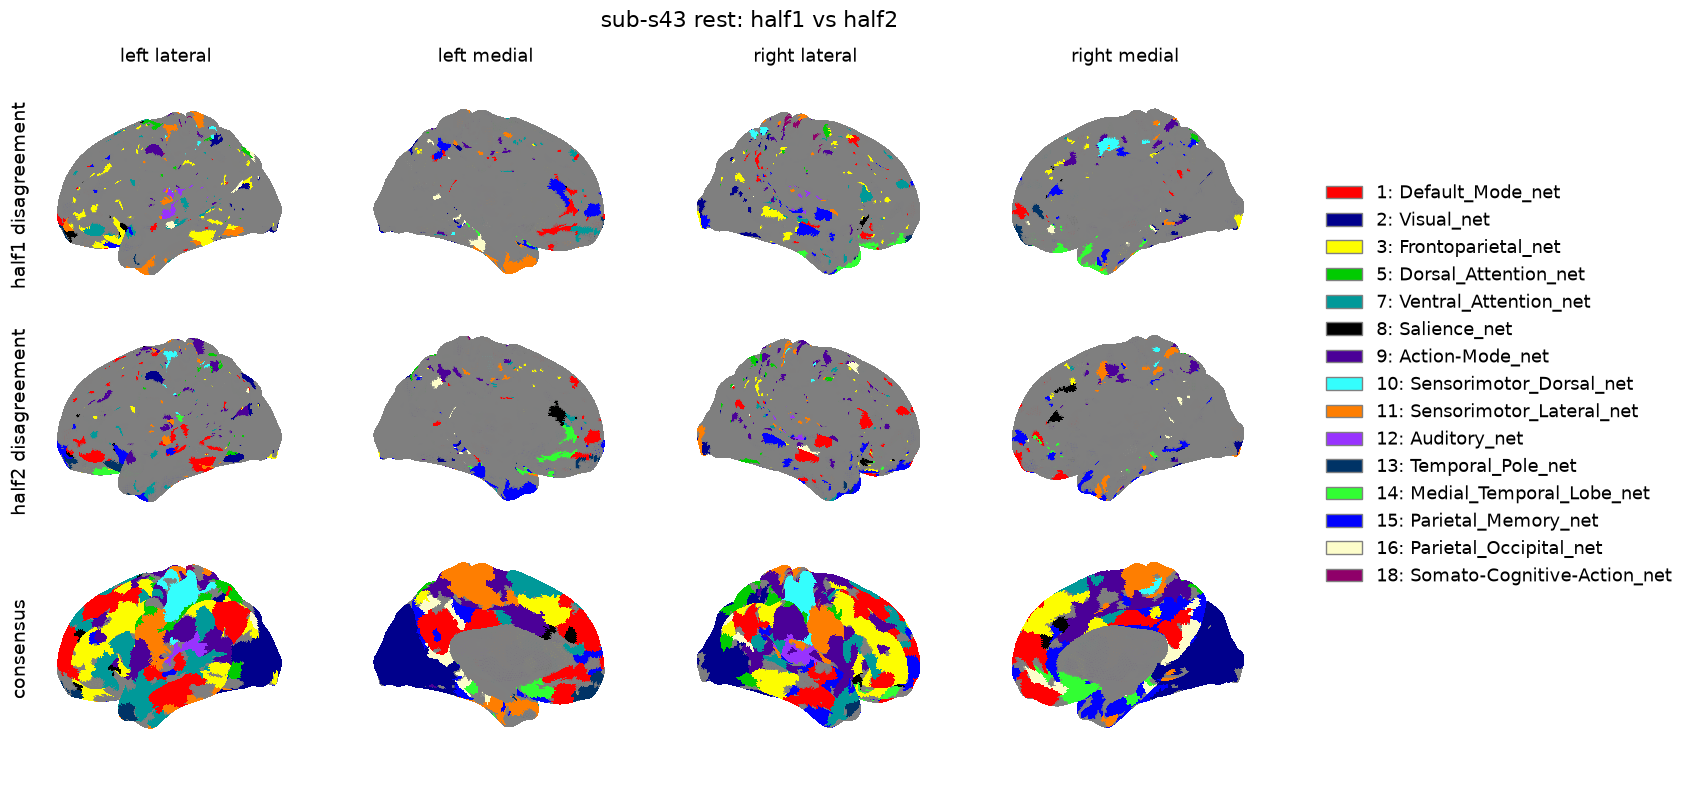

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s43/sub-s43_splithalf-task_disagreement_consensus_surfaces.png


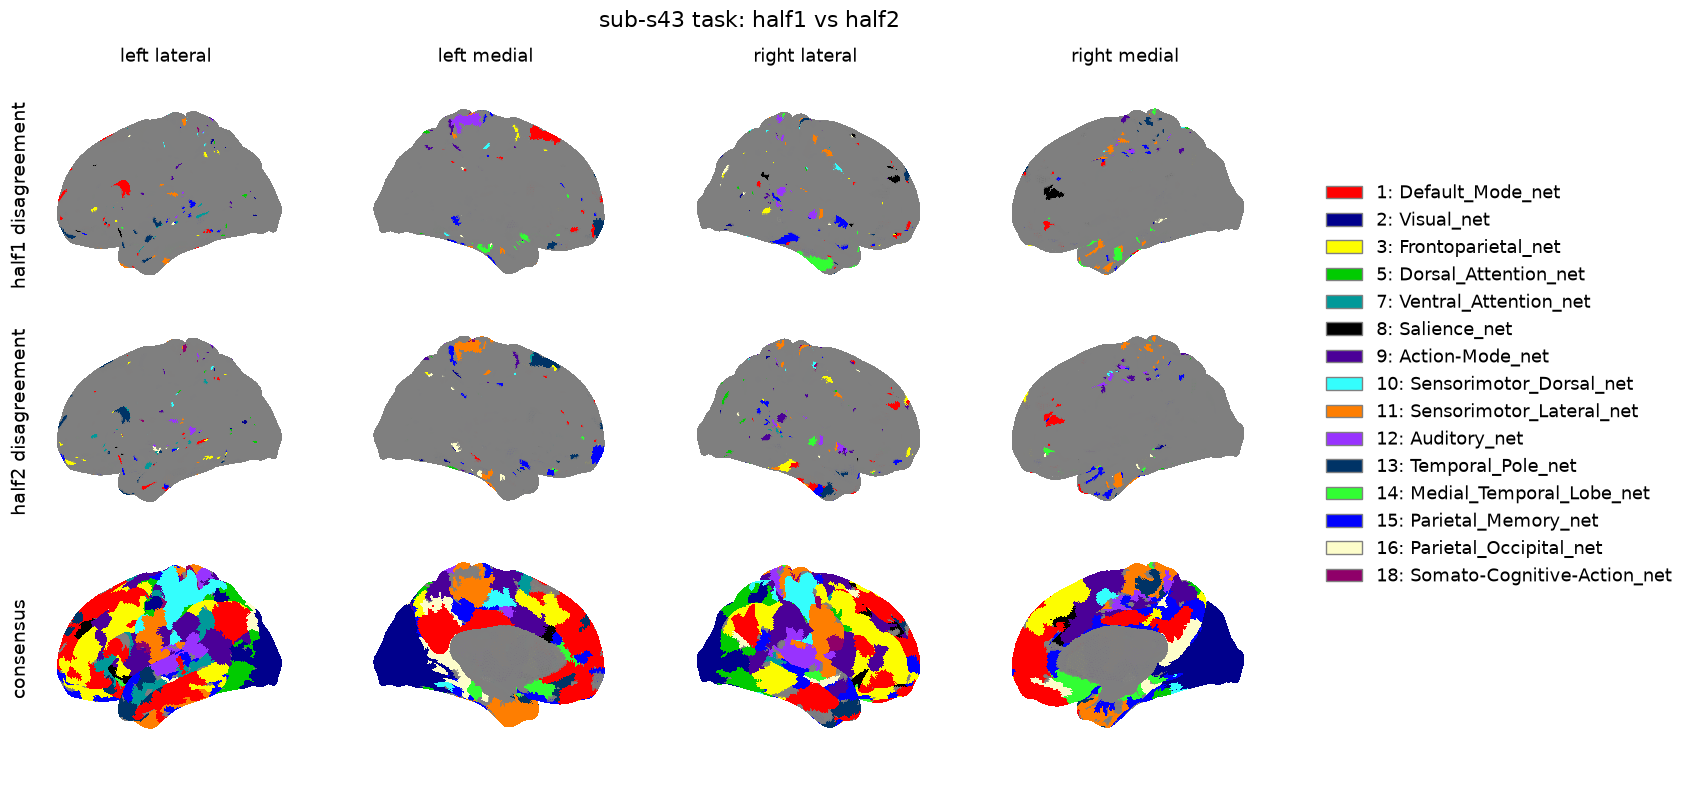

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/sub-s43/sub-s43_splithalf-task_resid_raw_disagreement_consensus_surfaces.png


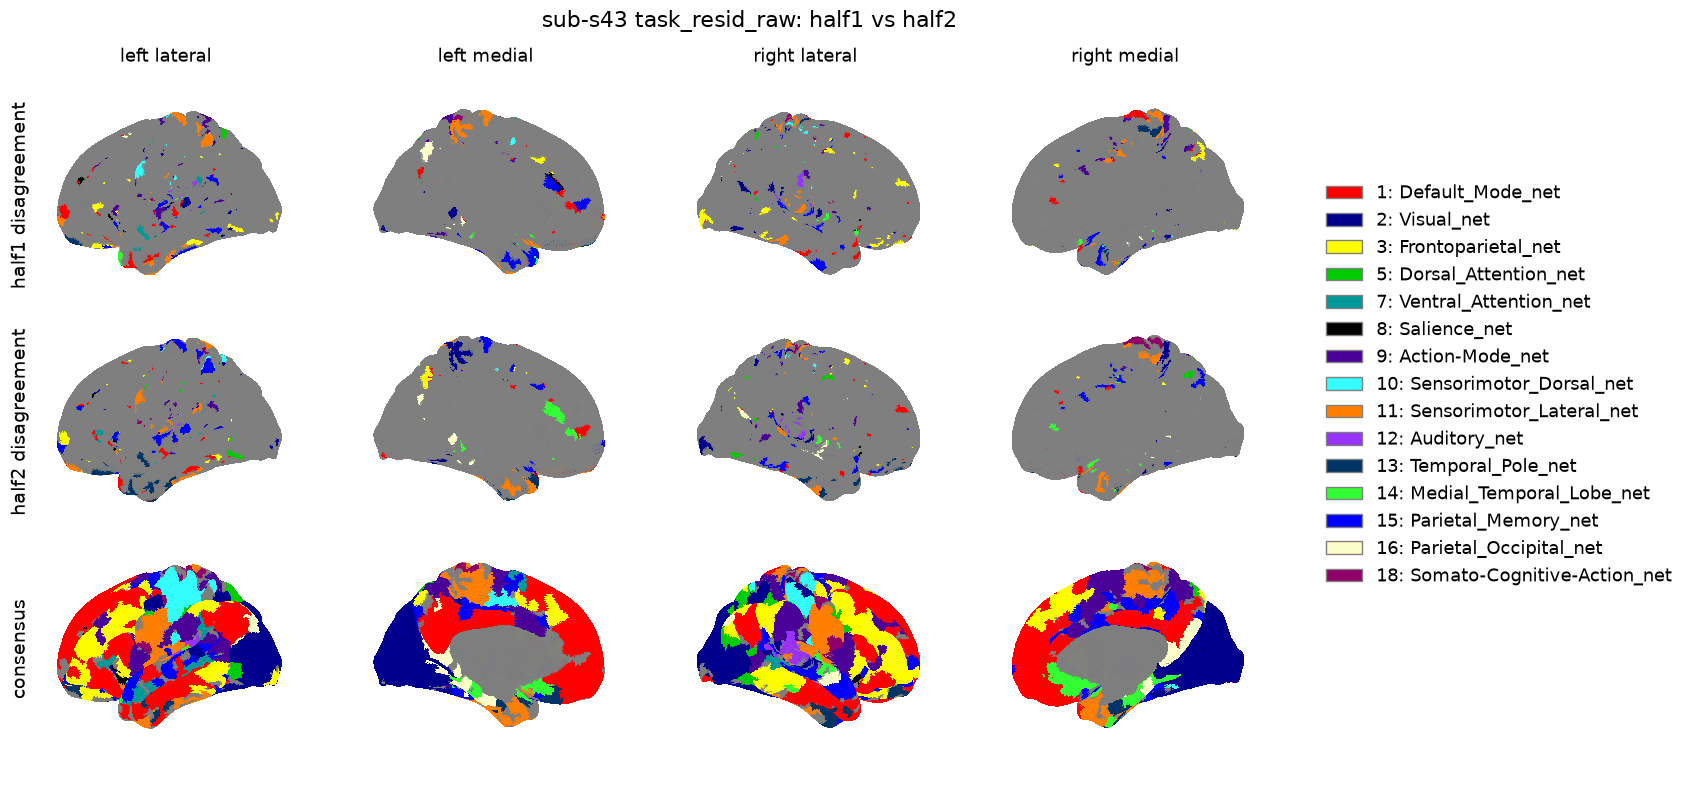

In [6]:
# surface figure for each subject and condition: disagreement rows + consensus row
for (subject, condition), result in results.items():
    comparison_name = comparison_names[condition]

    maps_to_plot = {
        f"{input_name} disagreement": result["paths"]["disagreement_paths"][input_name]
        for input_name in result["input_names"]
    }

    maps_to_plot["consensus"] = result["paths"]["consensus_path"]

    hemisphere_values_by_map, plotted_network_ids = pfm.load_hemisphere_values(
        maps_to_plot,
        map_index,
    )

    fig = pfm.plot_surface_grid(
        hemisphere_values_by_map,
        plotted_network_ids,
        surface_views,
        cmap=dlabel_network_cmap,
        color_min=color_min,
        color_max=color_max,
        network_labels=network_labels,
        network_colors=network_colors,
        title=f"{subject} {condition}: half1 vs half2",
        panel_zoom=panel_zoom,
        legend_fontsize=legend_fontsize,
    )

    surface_figure_path = (
        output_root
        / subject
        / f"{subject}_{comparison_name}_disagreement_consensus_surfaces.png"
    )

    fig.savefig(
        surface_figure_path,
        dpi=150,
        bbox_inches="tight",  # crop empty figure border
        pad_inches=0.05,  # margin left after cropping
    )

    result["paths"]["surface_figure_path"] = surface_figure_path

    print("Saved:", surface_figure_path)
    display(fig)

In [7]:
# group summary CSVs: every subject x condition stacked, with subject + condition columns
group_output_directory.mkdir(parents=True, exist_ok=True)

group_comparison_name = "splithalf_" + "_".join(
    pfm.safe_filename_component(condition)
    for condition in condition_config
)


def stack_summaries(summary_key):
    stacked = pd.concat(
        [
            result["overlap"][summary_key].assign(
                subject=subject,
                condition=condition,
            )
            for (subject, condition), result in results.items()
        ],
        ignore_index=True,
    )

    # subject + condition first
    leading_columns = ["subject", "condition"]

    return stacked[
        leading_columns
        + [c for c in stacked.columns if c not in leading_columns]
    ]


group_overall_summary = stack_summaries("overall_summary")
group_network_summary = stack_summaries("network_summary")

group_overall_summary_path = (
    group_output_directory
    / f"group_{group_comparison_name}_overall_summary.csv"
)

group_network_summary_path = (
    group_output_directory
    / f"group_{group_comparison_name}_network_summary.csv"
)

group_overall_summary.to_csv(group_overall_summary_path, index=False)
group_network_summary.to_csv(group_network_summary_path, index=False)

print("Saved:")
print(group_overall_summary_path)
print(group_network_summary_path)

display(
    group_overall_summary.pivot(
        index=["subject", "condition"],
        columns="category",
        values="count",
    )
)

Saved:
/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/group/group_splithalf_rest_task_task_resid_raw_overall_summary.csv
/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/group/group_splithalf_rest_task_task_resid_raw_network_summary.csv


category                Background or unlabelled in every input  \
subject condition                                                 
sub-s03 rest                                                950   
        task                                                762   
        task_resid_raw                                      796   
sub-s10 rest                                                951   
        task                                                833   
        task_resid_raw                                      909   
sub-s19 rest                                                730   
        task                                                563   
        task_resid_raw                                      539   
sub-s29 rest                                                992   
        task                                                869   
        task_resid_raw                                      720   
sub-s43 rest                                                663   
        task                                                595   
        task_resid_raw                                      539   

category                Consensus assignment  \
subject condition                              
sub-s03 rest                           69799   
        task                           82279   
        task_resid_raw                 80459   
sub-s10 rest                           72503   
        task                           80513   
        task_resid_raw                 78833   
sub-s19 rest                           71176   
        task                           81734   
        task_resid_raw                 80032   
sub-s29 rest                           72681   
        task                           81669   
        task_resid_raw                 77889   
sub-s43 rest                           72823   
        task                           82412   
        task_resid_raw                 77672   

category                Disagreement with at least one valid assignment  \
subject condition                                                         
sub-s03 rest                                                      20533   
        task                                                       8241   
        task_resid_raw                                            10027   
sub-s10 rest                                                      17828   
        task                                                       9936   
        task_resid_raw                                            11540   
sub-s19 rest                                                      19376   
        task                                                       8985   
        task_resid_raw                                            10711   
sub-s29 rest                                                      17609   
        task                                                       8744   
        task_resid_raw                                            12673   
sub-s43 rest                                                      17796   
        task                                                       8275   
        task_resid_raw                                            13071   

category                Total grayordinates  Valid assignment in every input  
subject condition                                                             
sub-s03 rest                          91282                            89920  
        task                          91282                            90375  
        task_resid_raw                91282                            90318  
sub-s10 rest                          91282                            90049  
        task                          91282                            90266  
        task_resid_raw                91282                            90138  
sub-s19 rest                          91282                            90385  
        task                          91282             

In [8]:
# split-half consensus % per subject and condition
# percent of grayordinates assigned in both halves that have the same network in both
consensus_by_subject = pd.DataFrame([
    {
        "subject": subject,
        "condition": condition,
        "consensus_count": int(result["overlap"]["consensus_mask"].sum()),
        "all_assigned_count": int(result["overlap"]["all_assigned"].sum()),
    }
    for (subject, condition), result in results.items()
])

consensus_by_subject["consensus_percent"] = (
    100
    * consensus_by_subject["consensus_count"]
    / consensus_by_subject["all_assigned_count"]
)

consensus_by_subject_path = (
    group_output_directory
    / f"group_{group_comparison_name}_consensus_percent.csv"
)

consensus_by_subject.to_csv(consensus_by_subject_path, index=False)

print("Saved:", consensus_by_subject_path)

display(
    consensus_by_subject.pivot(
        index="subject",
        columns="condition",
        values="consensus_percent",
    ).round(2)
)

Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/group/group_splithalf_rest_task_task_resid_raw_consensus_percent.csv


condition,rest,task,task_resid_raw
subject,,,
sub-s03,77.62,91.04,89.08
sub-s10,80.52,89.20,87.46
sub-s19,78.75,90.24,88.30
sub-s29,80.78,90.50,86.22
sub-s43,80.59,91.06,85.71


Saved: /oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/temp_match_overlap/23Sept2026_splithalf/network_overlap_outputs/group/group_splithalf_rest_task_task_resid_raw_consensus_percent.png


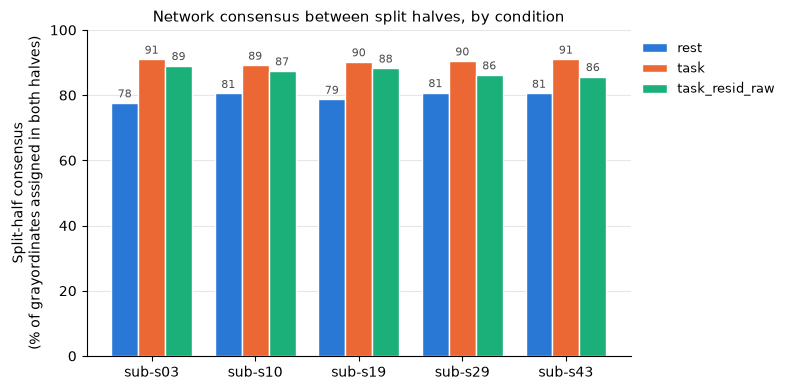

In [9]:
# grouped bar plot: one bar per condition within each subject
conditions = list(condition_config)

# fixed categorical order (validated: CVD-separable on white)
condition_colors = dict(zip(conditions, ["#2a78d6", "#eb6834", "#1baf7a"]))

bar_width = 0.26
x_positions = np.arange(len(subjects))

consensus_fig, ax = plt.subplots(
    figsize=(8, 4),
    facecolor="white",  # ipykernel's inline backend can default to transparent
)

for condition_index, condition in enumerate(conditions):
    condition_rows = (
        consensus_by_subject[consensus_by_subject["condition"] == condition]
        .set_index("subject")
        .loc[subjects]
    )

    offset = (condition_index - (len(conditions) - 1) / 2) * bar_width

    bars = ax.bar(
        x_positions + offset,
        condition_rows["consensus_percent"],
        width=bar_width,
        color=condition_colors[condition],
        edgecolor="white",  # small gap between adjacent bars
        linewidth=1,
        label=condition,
    )

    ax.bar_label(bars, fmt="%.0f", padding=2, fontsize=8, color="0.3")

ax.set_xticks(x_positions)
ax.set_xticklabels(subjects)
ax.set_ylim(0, 100)
ax.set_ylabel("Split-half consensus\n(% of grayordinates assigned in both halves)")
ax.set_title("Network consensus between split halves, by condition", fontsize=11)

ax.legend(frameon=False, fontsize=9, loc="upper left", bbox_to_anchor=(1.0, 1.0))

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="0.9", linewidth=0.8)
ax.set_axisbelow(True)

consensus_fig.tight_layout()

consensus_figure_path = (
    group_output_directory
    / f"group_{group_comparison_name}_consensus_percent.png"
)

consensus_fig.savefig(consensus_figure_path, dpi=150, bbox_inches="tight")

print("Saved:", consensus_figure_path)
plt.show()